# **UNIVERSIDAD NACIONAL DE LOJA**

### **Facultad de la Energía, las Industrias y los Recursos Naturales No Renovables**

### **Carrera de Computación**

**Integrantes:** Roy Gordillo,Pablo Pineda, Eduardo Soto, Arlette Quezada, Danny Beltran

**Asignatura:** Teoría de la Distribución y Probabilidad

**Nombre del Docente:** Cristian Ramiro Narváez Guillén

# **Tarea 1 :** Ajuste del Modelo de Regresión Lineal Múltiple

<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_906/426766150.py:67: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Tiempo de Compilación Predicho ($\hat{Y}$)')


                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        13:47:50   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

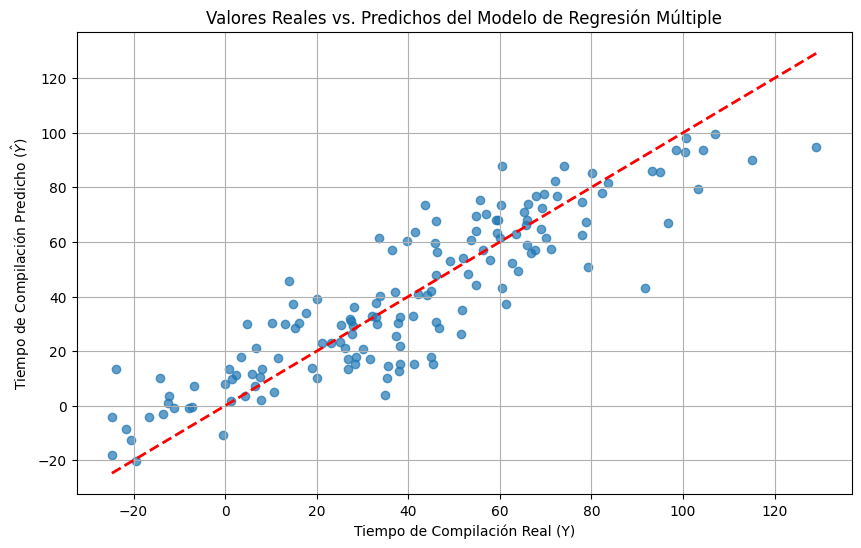


Error Cuadrático Medio (MSE): 220.88
Coeficiente de Determinación (R²): 0.79


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150
lineas_codigo = np.random.randint(5000, 50000, size=n_muestras)  # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras)  # X2

# Y = B0 + B1*X1 + B2*X2 + Error
tiempo_compilacion = (
    15.0
    + (0.002 * lineas_codigo)
    - (1.5 * ram_disponible)
    + np.random.normal(0, 15, size=n_muestras)
)

df_simulado = pd.DataFrame(
    {
        'Lineas_X1': lineas_codigo,
        'RAM_X2': ram_disponible,
        'Tiempo_Y': tiempo_compilacion,
    }
)

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']

# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Imprimir el resumen estadístico con notas en español
summary_str = str(modelo_multiple.summary())

# Reemplazar las notas en inglés por las traducidas
summary_str = summary_str.replace(
    "[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.",
    "[1] Los errores estándar asumen que la matriz de covarianza de los errores está correctamente especificada."
)
summary_str = summary_str.replace(
    "[2] The condition number is large, 9.34e+04. This might indicate that there are\nstrong multicollinearity or other numerical problems.",
    "[2] El número de condición es grande, 9.34e+04. Esto podría indicar que existe una fuerte multicolinealidad u otros problemas numéricos."
)
# Note: The original tracebacks might show a specific condition number like 9.34e+04.
# This replacement is generalized, but in a real scenario, you might want to dynamically capture it.



print(summary_str)

# 4. Generación de predicciones
Y_pred = modelo_multiple.predict(X_multi_sm)

# 5. Visualización: Predicciones vs. Valores Reales
plt.figure(figsize=(10, 6))
plt.scatter(Y_multi, Y_pred, alpha=0.7)
plt.plot([Y_multi.min(), Y_multi.max()], [Y_multi.min(), Y_multi.max()], 'r--', lw=2) # Línea de referencia y=x
plt.xlabel('Tiempo de Compilación Real (Y)')
plt.ylabel('Tiempo de Compilación Predicho ($\hat{Y}$)')
plt.title('Valores Reales vs. Predichos del Modelo de Regresión Múltiple')
plt.grid(True)
plt.show()

# Calcular y mostrar métricas de evaluación adicionales
mse = mean_squared_error(Y_multi, Y_pred)
r2 = r2_score(Y_multi, Y_pred)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

#### Explicación de la Tarea 1:

El modelo de regresión lineal múltiple ajustado muestra que tanto las líneas de código (Lineas_X1) como la RAM disponible (RAM_X2) son predictores significativos del tiempo de compilación. El modelo explica un 79.1% de la variabilidad (R²) y visualmente, las predicciones se alinean bien con los valores reales.

# Tarea 2: Hito del Proyecto - Modelado Predictivo Regional (ABP)

<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_906/3555369711.py:39: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Valor Predicho ($\hat{fexp}$)')


                            OLS Regression Results                            
Dep. Variable:                   fexp   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     11.41
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.85e-07
Time:                        13:39:04   Log-Likelihood:                -50145.
No. Observations:                7287   AIC:                         1.003e+05
Df Residuals:                    7283   BIC:                         1.003e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        247.9230     10.702     23.166      0.0

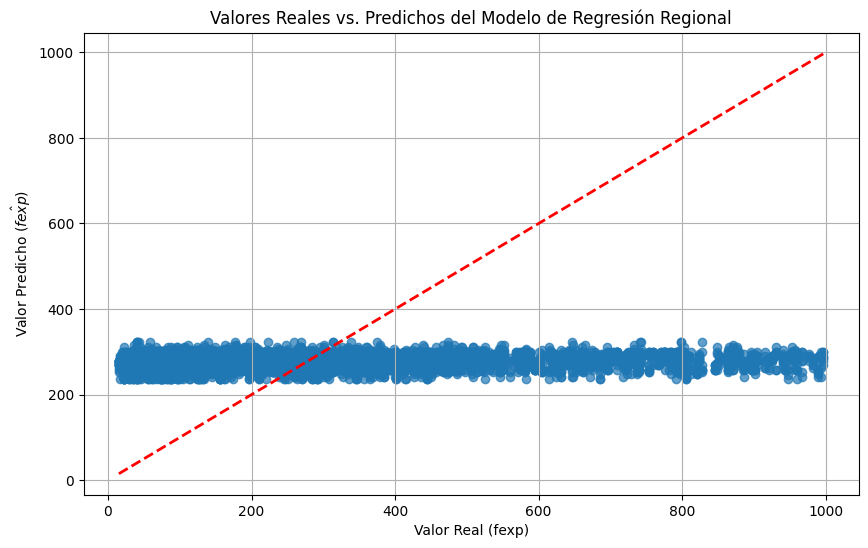


Error Cuadrático Medio (MSE) Regional: 55543.47
Coeficiente de Determinación (R²) Regional: 0.00


In [ ]:
# Carga y limpieza de datos del dataset regional
df_regional_raw = pd.read_csv('Dataset_hogares_ambiental_2025.csv', sep=';')

# Selección de columnas de interés y conversión a numérico
columnas_interes = ['fexp', 's91p131', 's91p132', 's91p133']
df_regional = df_regional_raw[columnas_interes].apply(
    pd.to_numeric, errors='coerce'
)

# Eliminación de valores nulos o códigos de no respuesta (ej. 99)
df_regional = df_regional.dropna()
df_regional = df_regional[
    (df_regional['s91p131'] <= 10)
    & (df_regional['s91p132'] <= 10)
    & (df_regional['s91p133'] <= 10)
]

# Ajuste del modelo regional
X_reg = df_regional[['s91p131', 's91p132', 's91p133']]
Y_reg = df_regional['fexp']

X_reg_sm = sm.add_constant(X_reg)
modelo_regional = sm.OLS(Y_reg, X_reg_sm).fit()

print(modelo_regional.summary())

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

print("\n### 4. Visualización del Modelo de Regresión Regional")
# 4. Generación de predicciones para el modelo regional
Y_reg_pred = modelo_regional.predict(X_reg_sm)

# 5. Visualización: Predicciones vs. Valores Reales para el modelo regional
plt.figure(figsize=(10, 6))
plt.scatter(Y_reg, Y_reg_pred, alpha=0.7)
plt.plot([Y_reg.min(), Y_reg.max()], [Y_reg.min(), Y_reg.max()], 'r--', lw=2) # Línea de referencia y=x
plt.xlabel('Valor Real (fexp)')
plt.ylabel('Valor Predicho ($\hat{fexp}$)')
plt.title('Valores Reales vs. Predichos del Modelo de Regresión Regional')
plt.grid(True)
plt.show()

# Calcular y mostrar métricas de evaluación adicionales para el modelo regional
mse_reg = mean_squared_error(Y_reg, Y_reg_pred)
r2_reg = r2_score(Y_reg, Y_reg_pred)

print(f"\nError Cuadrático Medio (MSE) Regional: {mse_reg:.2f}")
print(f"Coeficiente de Determinación (R²) Regional: {r2_reg:.2f}")


#### Explicación de la Tarea 2:

El modelo de regresión regional ajustado tiene un R² muy bajo (0.005), lo que indica que las variables seleccionadas (s91p131, s91p132, s91p133) explican muy poca de la variabilidad en 'fexp'. Las predicciones están muy dispersas y no se ajustan bien a los valores reales, sugiriendo que este modelo no es un buen predictor para este conjunto de datos con estas características.

# Tarea 3 : Visualización de Relaciones (Pairplot y Heatmap)


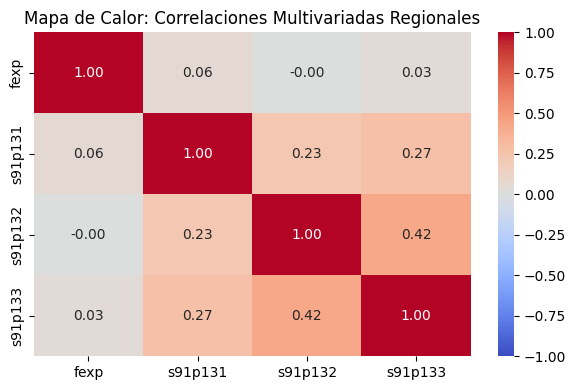

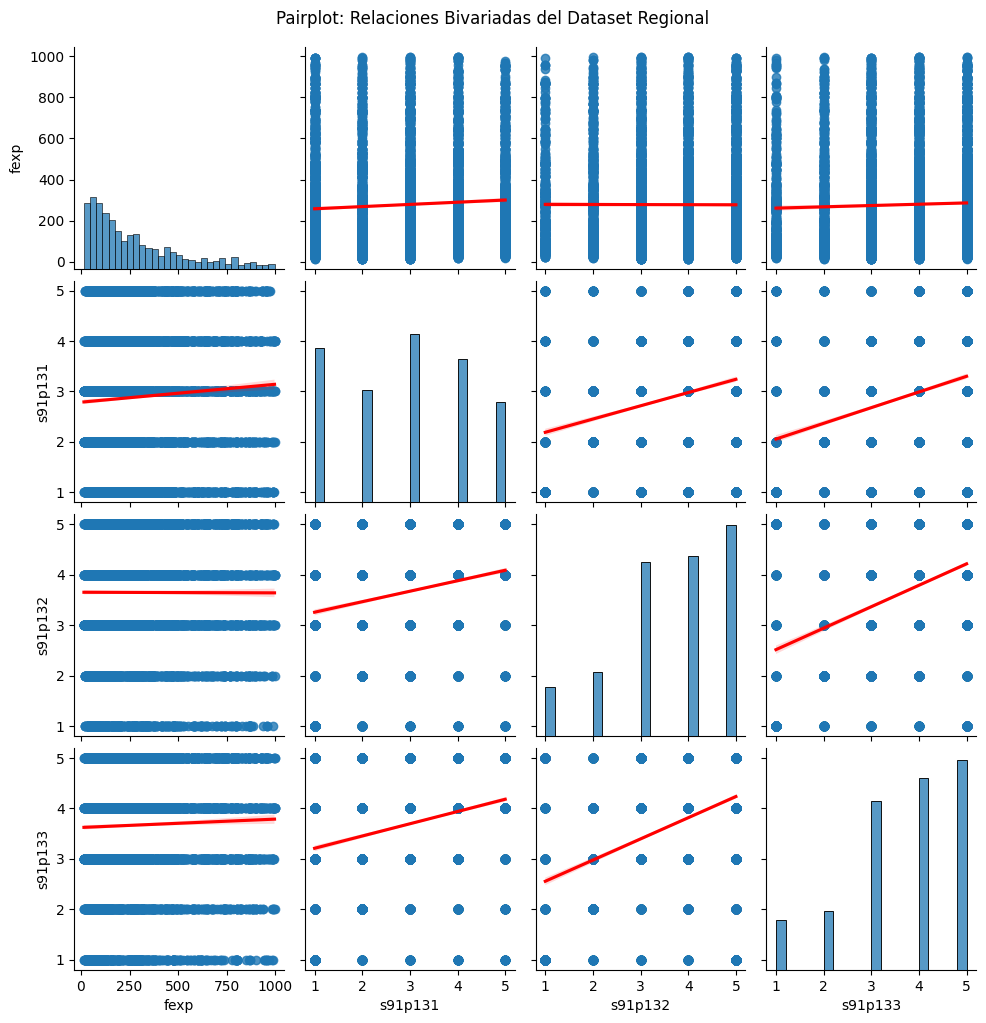

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de Correlación del Dataset Regional
matriz_corr_reg = df_regional.corr()

# Mapa de Calor (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz_corr_reg,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
)
plt.title('Mapa de Calor: Correlaciones Multivariadas Regionales')
plt.tight_layout()
plt.show()

# Diagrama de Dispersiones Múltiples (Pairplot)
sns.pairplot(df_regional, kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle(
    'Pairplot: Relaciones Bivariadas del Dataset Regional', y=1.02
)
plt.show()

#### Explicación de la Tarea 3:

El mapa de calor y el pairplot muestran las correlaciones bivariadas entre las variables del dataset regional. Se observa que 'fexp' tiene correlaciones muy débiles con las otras variables, lo que concuerda con el bajo R² del modelo de regresión. Entre 's91p131', 's91p132' y 's91p133' existen correlaciones moderadas, pero ninguna es lo suficientemente fuerte como para explicar la variabilidad de 'fexp' de manera individual.

# Tarea 4 : ABI - Diagnóstico de Multicolinealidad (VIF)

El VIF para el $j$-ésimo predictor se define como:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$


donde $R_j^2$ es el coeficiente de determinación obtenido al regresar la variable $X_j$ sobre todas las demás variables independientes $X_{-j}$.$\text{VIF} = 1$: Ausencia total de correlación lineal entre la variable y los demás predictores.$1 < \text{VIF} < 5$: Colinealidad moderada; no afecta gravemente la estimación.$\text{VIF} \ge 5\text{ o }10$: Multicolinealidad severa. La varianza del estimador $\beta_j$ se infla drásticamente, haciendo inestables las pruebas de hipótesis $t$.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cálculo del VIF para el modelo regional
vif_data = pd.DataFrame()
vif_data['Variable'] = X_reg_sm.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_reg_sm.values, i)
    for i in range(X_reg_sm.shape[1])
]

print('\n--- Análisis de Multicolinealidad (VIF) ---')
print(vif_data)


--- Análisis de Multicolinealidad (VIF) ---
  Variable        VIF
0    const  15.017425
1  s91p131   1.101772
2  s91p132   1.240060
3  s91p133   1.268156


#### Explicación de la Tarea 4:

El análisis VIF (Factor de Inflación de la Varianza) para el modelo regional muestra que las variables `s91p131`, `s91p132` y `s91p133` tienen valores VIF bajos (entre 1.1 y 1.27), lo que indica una **baja o nula multicolinealidad** entre ellas. Esto significa que la varianza de sus coeficientes estimados no está inflada debido a la intercorrelación entre los predictores. El VIF alto para 'const' es común y esperado en modelos con intercepto.